In [2]:
from sklearn import tree
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

In [77]:
!uv pip list

^C


In [ ]:
!uv pip show graphviz

Name: graphviz
Version: 0.20.3
Location: D:\envs\scikit_learn\Lib\site-packages
Requires:
Required-by:


Using Python 3.8.20 environment at: D:\envs\scikit_learn


## 导入数据集 查看基本信息

In [ ]:
wine = load_wine()
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [ ]:
wine.data

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]])

In [ ]:
wine.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [ ]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [ ]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

这个数据集是一个三分类的，目标有012三个

In [ ]:
import pandas as pd

In [ ]:
# 用 concat 把数据中和标签连接成一个dataframe
df = pd.concat([pd.DataFrame(wine.data), pd.DataFrame(wine.target)], axis=1)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,0
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 划分训练集和测试集

In [ ]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(wine.data, wine.target, test_size=0.3)

In [ ]:
print(Xtrain.shape, Xtest.shape)

(124, 13) (54, 13)


## 训练决策树

In [ ]:
clf = tree.DecisionTreeClassifier(criterion="entropy", random_state=42)
clf.fit(Xtrain, Ytrain)
clf.score(Xtest, Ytest)
# 可以发现每次运行的结果不同，可以指定

0.9444444444444444

## 导出绘图

In [ ]:
import graphviz


(process:3028): Pango-WARNING **: 12:34:10.376: couldn't load font "霞鹜文楷 Not-Rotated 14", falling back to "Sans Not-Rotated 14", expect ugly output.


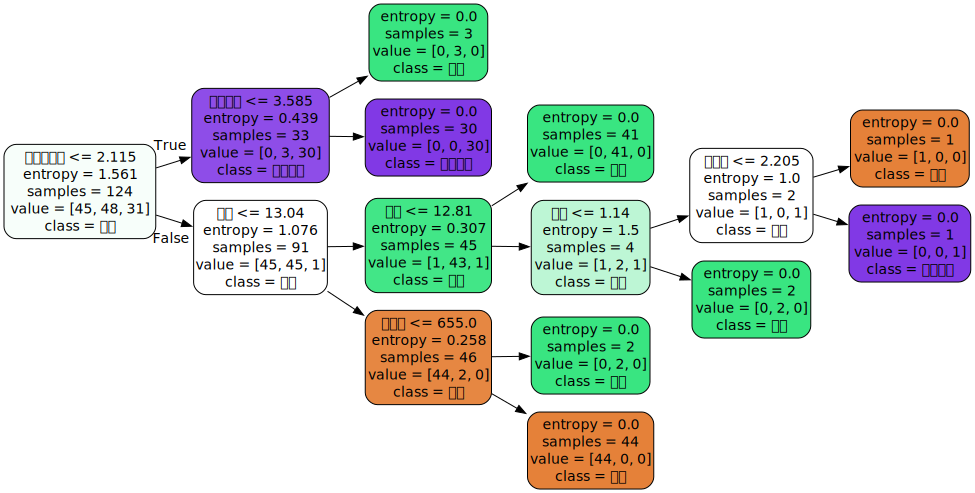

In [ ]:
feature_name = ['酒精','苹果酸','灰','灰的碱性','镁','总酚','类黄酮','非黄烷类酚类','花青素','颜色强度','色调','稀释葡萄酒','脯氨酸']

dot_data = tree.export_graphviz(clf, 
                                feature_names=feature_name,
                                class_names=["琴酒", "雪莉", "贝尔摩德"],
                                filled=True,
                                rounded=True,
                                rotate=True,
                                fontname="霞鹜文楷"
                                )

graph = graphviz.Source(dot_data)
graph

最后的叶子节点不纯度为0，表示可以选取具体的类别

- filled表示是否给节点上色，越靠近叶节点的颜色越深，不纯度**越低**。
- rounded 表示边框是否有圆角

查看各个特征的重要程度：

In [ ]:
clf.feature_importances_

array([0.41375614, 0.01033439, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.07494187,
       0.02066877, 0.41897014, 0.06132869])

In [ ]:
# 这里可以zip一下
sorted(zip(feature_name, clf.feature_importances_), key=lambda x: x[1], reverse=True)

[('稀释葡萄酒', 0.41897014219437223),
 ('酒精', 0.4137561420003343),
 ('颜色强度', 0.07494187169283383),
 ('脯氨酸', 0.061328685367992894),
 ('色调', 0.020668772496311178),
 ('苹果酸', 0.010334386248155589),
 ('灰', 0.0),
 ('灰的碱性', 0.0),
 ('镁', 0.0),
 ('总酚', 0.0),
 ('类黄酮', 0.0),
 ('非黄烷类酚类', 0.0),
 ('花青素', 0.0)]

In [ ]:
clf_random = tree.DecisionTreeClassifier(
    criterion="entropy", 
    splitter="random", 
    random_state=30,
    max_depth=3,
    min_samples_leaf=3,
    min_samples_split=13
    )

clf_random.fit(Xtrain, Ytrain)

clf_random.score(Xtest, Ytest)

0.7592592592592593


(process:13116): Pango-WARNING **: 16:25:28.838: couldn't load font "霞鹜文楷 Not-Rotated 14", falling back to "Sans Not-Rotated 14", expect ugly output.


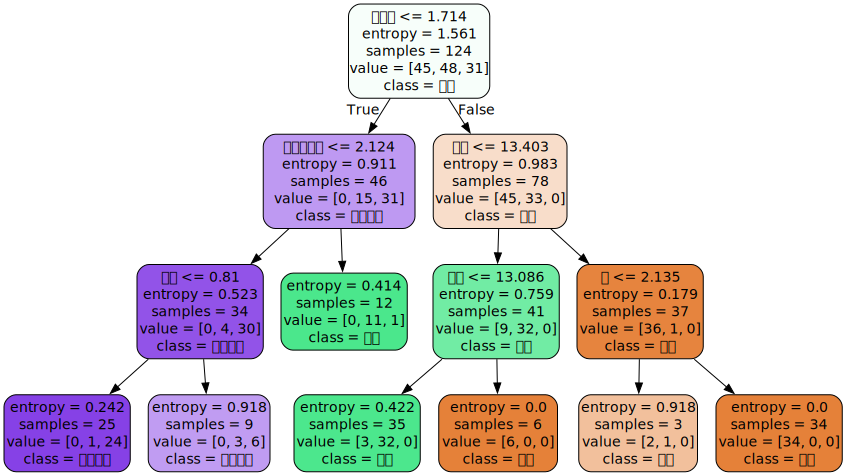

In [ ]:
dot_data_random = tree.export_graphviz(clf_random, 
                                feature_names=feature_name,
                                class_names=["琴酒", "雪莉", "贝尔摩德"],
                                filled=True,
                                rounded=True,
                                # rotate=True,
                                fontname="霞鹜文楷",
                                )

graph_random = graphviz.Source(dot_data_random)
graph_random

## 超参数曲线

In [ ]:
from matplotlib import pyplot as plt

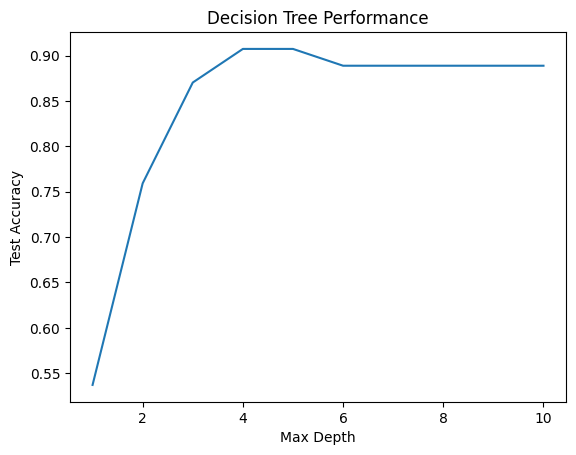

In [ ]:
test = []

for i in range(10):
    clf = tree.DecisionTreeClassifier(max_depth=i+1, random_state=42, splitter="random", criterion="entropy")
    clf.fit(Xtrain, Ytrain)
    score = clf.score(Xtest, Ytest)
    test.append(score)
    
plt.plot(range(1,11), test)
plt.xlabel("Max Depth")
plt.ylabel("Test Accuracy")
plt.title("Decision Tree Performance")
plt.show()

In [ ]:
# 这里的 max_depth 为 10
clf.apply(Xtest)

array([ 3, 20,  3,  2,  2, 20,  3,  3,  3,  7, 20,  3,  7,  7,  3,  7, 20,
       20, 10,  7,  7,  7,  3,  3, 16,  3, 16,  3, 10,  3, 16,  3,  7, 20,
       16,  7, 16,  7,  7,  7,  3,  3,  7, 20,  7, 16,  7,  7,  3, 20, 20,
       20,  3, 16], dtype=int64)

In [ ]:
clf.predict(Xtest)

array([2, 0, 2, 1, 1, 0, 2, 2, 2, 1, 0, 2, 1, 1, 2, 1, 0, 0, 1, 1, 1, 1,
       2, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 0, 0, 1, 0, 1, 1, 1, 2, 2, 1, 0,
       1, 0, 1, 1, 2, 0, 0, 0, 2, 0])

## 回归树

### 交叉验证

In [ ]:
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor

In [ ]:
diabetes = load_diabetes()
housing = fetch_california_housing()
regressor = DecisionTreeRegressor(random_state=42)
cross_val_score(
    regressor, 
    housing.data, 
    housing.target, 
    cv=10,
    # 不填scoring 默认返回R^2
    scoring="neg_mean_squared_error"
    )

array([-1.21135398, -0.76611675, -0.71643382, -0.4978003 , -0.78924236,
       -0.84220232, -0.55256812, -1.02057649, -1.03621216, -0.55164701])

### 回归树实例

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

In [ ]:
rng = np.random.RandomState(42)
X = np.sort(5 * rng.rand(80, 1), axis=0)
X

array([[0.02761059],
       [0.10292247],
       [0.17194261],
       [0.22613644],
       [0.23225206],
       [0.29041806],
       [0.32525796],
       [0.37022326],
       [0.37275322],
       [0.44246251],
       [0.48836057],
       [0.5793453 ],
       [0.61019117],
       [0.6974693 ],
       [0.70462112],
       [0.7799726 ],
       [0.7800932 ],
       [0.85262062],
       [0.90912484],
       [0.91702255],
       [0.92427228],
       [0.97991431],
       [0.99357841],
       [0.99836891],
       [1.06169555],
       [1.29389991],
       [1.35674516],
       [1.40467255],
       [1.4561457 ],
       [1.46072324],
       [1.52121121],
       [1.52306885],
       [1.55855538],
       [1.62665165],
       [1.78376663],
       [1.79232864],
       [1.83180922],
       [1.87270059],
       [1.94338645],
       [2.15972509],
       [2.20076247],
       [2.28034992],
       [2.47588455],
       [2.57117219],
       [2.60034011],
       [2.62378216],
       [2.71348042],
       [2.733

In [ ]:
# 降维
y = np.sin(X).ravel()
y

array([ 0.02760708,  0.10274086,  0.17109663,  0.22421402,  0.2301697 ,
        0.2863528 ,  0.31955324,  0.36182357,  0.36418096,  0.42816613,
        0.46917873,  0.54747619,  0.57302415,  0.64228004,  0.64774523,
        0.70325994,  0.70334567,  0.75300739,  0.78896631,  0.7937943 ,
        0.79818258,  0.83044964,  0.83798406,  0.84058858,  0.87318314,
        0.9619085 ,  0.97717839,  0.98623315,  0.99343481,  0.99394807,
        0.99877091,  0.99886126,  0.99992508,  0.9984405 ,  0.97740741,
        0.97556191,  0.96612909,  0.95477201,  0.93138759,  0.83153619,
        0.80804746,  0.75865278,  0.6176162 ,  0.53998599,  0.51520991,
        0.49497885,  0.41515415,  0.39681216,  0.17855712,  0.15150706,
        0.14775724,  0.13559858,  0.10368173,  0.08223521, -0.17018634,
       -0.27594475, -0.3826788 , -0.38828536, -0.48244437, -0.49547106,
       -0.65543548, -0.65910736, -0.66989805, -0.70632074, -0.7639369 ,
       -0.78357182, -0.80502315, -0.84260101, -0.85243263, -0.92

In [ ]:
# y[::4] += 0.3 * rng.randn()
y[::10] +=  3* ( rng.rand(8) - 0.5 )

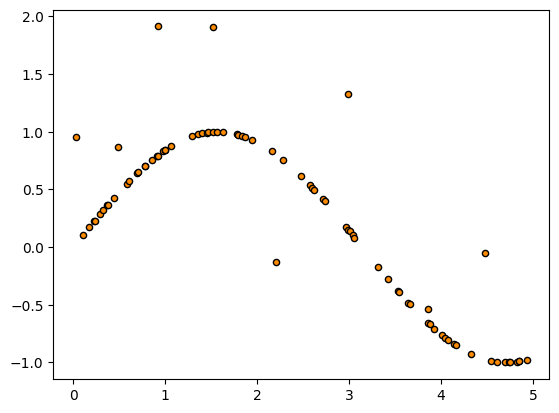

In [ ]:
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")

In [ ]:
regr1 = DecisionTreeRegressor(max_depth=2, random_state=42)
regre2 = DecisionTreeRegressor(max_depth=5, random_state=42)

regr1.fit(X, y)
regre2.fit(X, y)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
# 不包括终点值
X_test = np.arange(0, 5, 0.01)[:, np.newaxis]
y_1 = regr1.predict(X_test)
y_2 = regre2.predict(X_test)

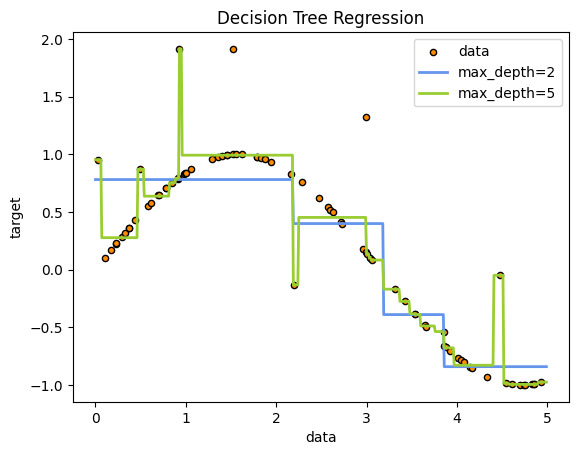

In [ ]:
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)    
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

## Titanic

In [3]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
import matplotlib.pyplot as plt

In [7]:
data = pd.read_csv("train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 预处理

In [8]:
data.drop(["PassengerId", "Name", "Ticket", "Cabin"], inplace=True, axis=1)
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [9]:
data["Age"] = data["Age"].fillna(data["Age"].mean())

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [11]:
data = data.dropna()

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


In [13]:
embarked = data["Embarked"].unique().tolist()
embarked

['S', 'C', 'Q']

In [14]:
map_embarked = dict(zip(embarked, range(len(embarked))))
map_embarked

{'S': 0, 'C': 1, 'Q': 2}

In [15]:
data["Embarked"] = data["Embarked"].map(map_embarked)
data

C:\Users\Linkwood\AppData\Local\Temp\ipykernel_47976\2755880628.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Embarked"] = data["Embarked"].map(map_embarked)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.000000,1,0,7.2500,0
1,1,1,female,38.000000,1,0,71.2833,1
2,1,3,female,26.000000,0,0,7.9250,0
3,1,1,female,35.000000,1,0,53.1000,0
4,0,3,male,35.000000,0,0,8.0500,0
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,0
887,1,1,female,19.000000,0,0,30.0000,0
888,0,3,female,29.699118,1,2,23.4500,0
889,1,1,male,26.000000,0,0,30.0000,1


In [16]:
data["Sex"] = data["Sex"].map(lambda x: 1 if x == "male" else 0)
data.head()

C:\Users\Linkwood\AppData\Local\Temp\ipykernel_47976\3222810963.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Sex"] = data["Sex"].map(lambda x: 1 if x == "male" else 0)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0
1,1,1,0,38.0,1,0,71.2833,1
2,1,3,0,26.0,0,0,7.9250,0
3,1,1,0,35.0,1,0,53.1000,0
4,0,3,1,35.0,0,0,8.0500,0


### 划分数据集    

In [17]:
x = data.iloc[:, data.columns != "Survived"]
y = data.iloc[:, data.columns == "Survived"]
print(x.shape, y.shape)

(889, 7) (889, 1)


In [18]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(x, y, test_size=0.3, random_state=42)
print(Xtrain.shape, Ytrain.shape)

(622, 7) (622, 1)


In [19]:
for data_set in [Xtrain, Ytrain, Xtest, Ytest]:
    data_set.reset_index(drop=True, inplace=True)

In [20]:
Xtrain.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,35.0,1,0,90.0000,0
1,3,0,24.0,0,0,8.8500,0
2,3,1,21.0,0,0,7.9250,0
3,2,1,36.0,1,2,27.7500,0
4,2,1,29.0,1,0,27.7208,1


In [21]:
Ytrain.head()

,Survived
0,1
1,0
2,0
3,0
4,0


### 训练

In [ ]:
clf = DecisionTreeClassifier(random_state=42)
clf = clf.fit(Xtrain, Ytrain)
score = clf.score(Xtest, Ytest)
print(score)

0.6292134831460674


In [ ]:
clf1 = DecisionTreeClassifier(random_state=42)
score = cross_val_score(clf1, x, y, cv=10).mean()
score

0.6524897854954035

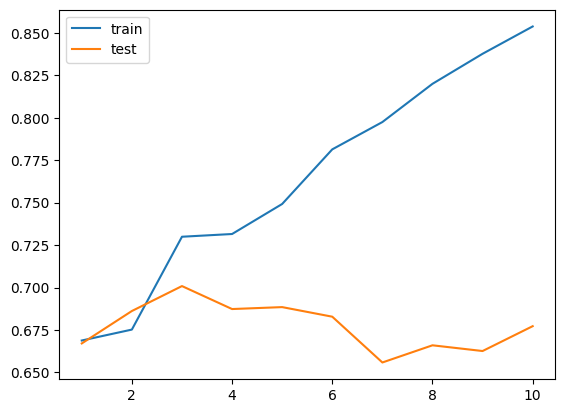

In [ ]:
tr = []
te = []

for i in range(10):
    clf = DecisionTreeClassifier(
        max_depth=i+1, 
        random_state=42,
        # criterion="entropy"
    )
    
    clf = clf.fit(Xtrain, Ytrain)
    score_tr = clf.score(Xtrain, Ytrain)
    # print(score_tr)
    score_te = cross_val_score(clf, x, y, cv=10).mean()
    tr.append(score_tr)
    te.append(score_te)
    

plt.plot(range(1,11), tr, label="train")
plt.plot(range(1,11), te, label="test")
plt.legend()
plt.show()

### 网格搜索

通过枚举调整多个参数

In [22]:
import numpy as np

In [23]:
parameter ={
    "criterion": ("gini", "entropy"),
    "splitter": ("best", "random"),
    "max_depth": [*range(1,10)],
    "min_samples_leaf": [*range(1,40,5)],
    "min_impurity_decrease": [*np.linspace(0, 0.5, 10)]
}

# 需要控制好参数的搜索范围
clf = DecisionTreeClassifier(random_state=42)
GS = GridSearchCV(clf, parameter, cv=10)
GS = GS.fit(Xtrain, Ytrain)
print("ok")

ok


In [1]:
GS

NameError: name 'GS' is not defined